In [1]:
import tensorflow as tf
import numpy as np

In [2]:
# Training parameters.
training_steps = 10000
batch_size = 64
latent_dim = 2

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [4]:
# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Normalize images value from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.

# Reshape for input images with a single channel
x_train, x_test = np.expand_dims(x_train, axis=-1), np.expand_dims(x_test, axis=-1)

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Flatten, \
                                    Dense, Reshape, Input, Lambda

# create encoder layers
conv1 = Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='relu', 
            input_shape=(28,28,1), padding="same")
maxpool1 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
conv2 = Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid')
maxpool2 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
flat = Flatten()
dense = Dense(latent_dim + latent_dim)

# create decoder layers
dense_T = Dense(400, activation='relu')
reshape = Reshape((5, 5, 16))
upsample1 = UpSampling2D(size=(2, 2))
conv1_T = Conv2DTranspose(16, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid')
upsample2 = UpSampling2D(size=(2, 2))
conv2_T = Conv2DTranspose(6, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='same')
output_T = Conv2DTranspose(1, kernel_size=(3, 3), padding='same')

In [6]:
def vae(x, output_apply_sigmoid=False):
    # define encoder
    _conv1 = conv1(x)
    _maxpool1 = maxpool1(_conv1)
    _conv2 = conv2(_maxpool1)
    _maxpool2 = maxpool2(_conv2)
    _flat = flat(_maxpool2)
    _dense = dense(_flat)

    mean, logvar = tf.split(_dense, num_or_size_splits=2, axis=1)

    epsilon = tf.random.normal(shape=tf.shape(mean))
    z = mean + tf.exp(0.5 * logvar) * epsilon
    #z = sampling([mean, logvar])

    # define decoder
    _dense_T = dense_T(z)
    _reshape = reshape(_dense_T)
    _upsample1 = upsample1(_reshape)
    _conv1_T = conv1_T(_upsample1)
    _upsample2 = upsample2(_conv1_T)
    _conv2_T = conv2_T(_upsample2)
    logits = output_T(_conv2_T)
    
    if output_apply_sigmoid:
        probs = tf.sigmoid(logits)
        return probs, mean, logvar
    return logits, mean, logvar

In [7]:
# define model
input_img = tf.keras.Input(shape=(28, 28, 1))
output_img, mean, logvar = vae(input_img)
model = tf.keras.Model(input_img, [output_img, mean, logvar], name="encoder")
model.summary()

Model: "encoder"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 28, 28, 1)]  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 28, 28, 6)    156         input_1[0][0]                    
__________________________________________________________________________________________________
max_pooling2d (MaxPooling2D)    (None, 14, 14, 6)    0           conv2d[0][0]                     
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 10, 10, 16)   2416        max_pooling2d[0][0]              
____________________________________________________________________________________________

In [8]:
def compute_loss(x, x_generated, mean, logvar):
    reconstruction_error = tf.reduce_sum(tf.square(x - x_generated), axis=[1, 2, 3])
    KL_divergence = 0.5 * tf.reduce_sum(tf.exp(logvar) - logvar + tf.square(mean) - 1, axis=1)
    vae_loss = tf.reduce_mean(reconstruction_error + KL_divergence)
    
    return vae_loss

In [9]:
from IPython import display
import time

# Use tf.data API to shuffle and batch data.
train_data=tf.data.Dataset.from_tensor_slices(x_train)
train_data=train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

# Adam optimizer.
optimizer = tf.optimizers.Adam()

start_time = time.time()
for step, batch_x in enumerate(train_data.take(training_steps), 1):
    with tf.GradientTape() as tape:
        x_out, z_mean, z_logvar = model(batch_x)
        loss = compute_loss(batch_x, x_out, z_mean, z_logvar)
        
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if step % 100 == 0:
        end_time = time.time()
        
        x_out, z_mean, z_logvar = model(x_test)
        loss = compute_loss(x_test, x_out, z_mean, z_logvar)
        print('Step: {}, Test set loss: {}, time elapse for current epoch: {}'
              .format(step, loss, end_time - start_time))
        
        start_time = time.time()

Step: 100, Test set loss: 47.98936080932617, time elapse for current epoch: 2.5634493827819824
Step: 200, Test set loss: 39.06045150756836, time elapse for current epoch: 1.3954179286956787
Step: 300, Test set loss: 36.66815185546875, time elapse for current epoch: 1.395139217376709
Step: 400, Test set loss: 36.13486862182617, time elapse for current epoch: 1.39389967918396
Step: 500, Test set loss: 34.83990478515625, time elapse for current epoch: 1.390242099761963
Step: 600, Test set loss: 33.91453170776367, time elapse for current epoch: 1.387948751449585
Step: 700, Test set loss: 33.65753936767578, time elapse for current epoch: 1.3900020122528076
Step: 800, Test set loss: 33.679344177246094, time elapse for current epoch: 1.3885090351104736
Step: 900, Test set loss: 33.261539459228516, time elapse for current epoch: 1.3853542804718018
Step: 1000, Test set loss: 32.8237419128418, time elapse for current epoch: 1.3882863521575928
Step: 1100, Test set loss: 32.72737503051758, time el

In [10]:
decoded_imgs, _, _ = model.predict(x_test)

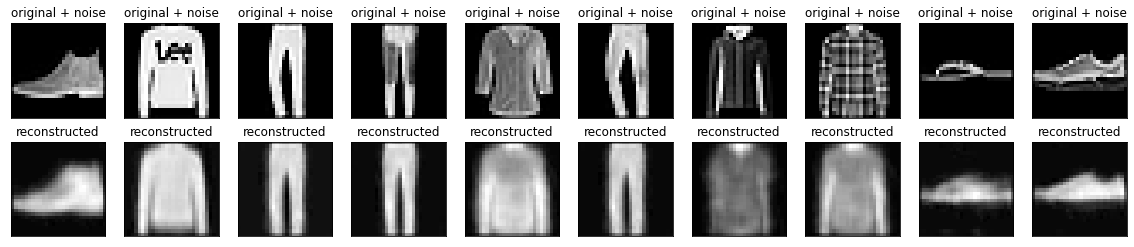

In [11]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    # display original + noise
    ax = plt.subplot(2, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    bx = plt.subplot(2, n, i + n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()

In [12]:
def vae_decoder(z):
    # define decoder
    _dense_T = dense_T(z)
    _reshape = reshape(_dense_T)
    _upsample1 = upsample1(_reshape)
    _conv1_T = conv1_T(_upsample1)
    _upsample2 = upsample1(_conv1_T)
    _conv2_T = conv2_T(_upsample2)
    logits = output_T(_conv2_T)

    return logits

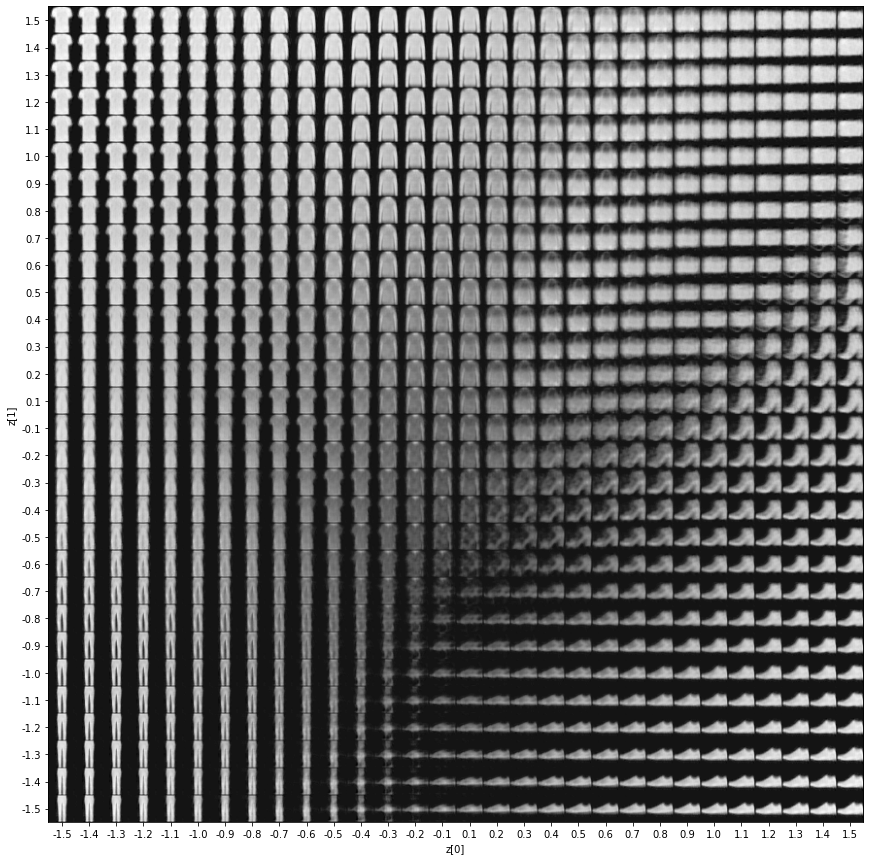

In [20]:
def plot_latent_space(n=30, figsize=15):
    # display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.5
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae_decoder(z_sample)
            digit = tf.reshape(x_decoded[0], shape=(digit_size, digit_size))
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space()

In [14]:
def model_encoder(x):
    # define encoder
    _conv1 = conv1(x)
    _maxpool1 = maxpool1(_conv1)
    _conv2 = conv2(_maxpool1)
    _maxpool2 = maxpool2(_conv2)
    _flat = flat(_maxpool2)
    
    _dense = dense(_flat)
    mean, _ = tf.split(_dense, num_or_size_splits=2, axis=1)
    return mean

(10000, 2)


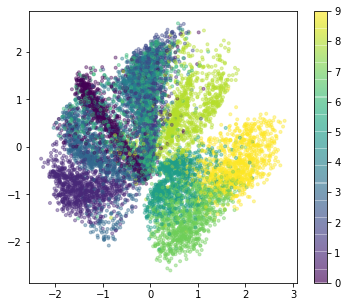

In [19]:
z_test = model_encoder(x_test)
fig, ax = plt.subplots(figsize=(6, 5))
cbar = ax.scatter(z_test[:, 0], z_test[:, 1], 
                  c=y_test, alpha=.4, s=3**2,
                  cmap='viridis')

fig.colorbar(cbar, ax=ax)

plt.show()